## IMPORTS

In [1]:
from bliss import *

# ============================================================
# 0. Imports and project path
# ============================================================

from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

#if str(PROJECT_ROOT) not in sys.path:
#    sys.path.insert(0, str(PROJECT_ROOT))
from matplotlib.lines import Line2D
import time

In [2]:
import sys
import bliss

print("Python:", sys.executable)
print("BLiSS file:", bliss.__file__)
print("BLiSS module:", bliss)

Python: /opt/homebrew/anaconda3/bin/python
BLiSS file: /Users/graciela/Desktop/git/BLiSS/bliss/__init__.py
BLiSS module: <module 'bliss' from '/Users/graciela/Desktop/git/BLiSS/bliss/__init__.py'>


In [3]:
from pathlib import Path
import bliss.line_search.blind_line_search as bls

path = Path(bls.__file__)
print(path)
print("fit_error_flag" in path.read_text())

/Users/graciela/Desktop/git/BLiSS/bliss/line_search/blind_line_search.py
True


In [4]:
import bliss.line_search.blind_line_search as bls

print("In file:", "fit_error_flag" in open(bls.__file__).read())
print("In module:", "fit_error_flag" in bls.FINAL_OUTPUT_COLUMNS)
print(bls.FINAL_OUTPUT_COLUMNS)

In file: True
In module: True
['center', 'ecenter', 'sigma', 'esigma', 'amplitude', 'eamplitude', 'relative_power', 'noise_on_block', 'value_on_line', 'base_on_line', 'snr_peak', 'snr_amplitude', 'area', 'earea', 'snr_area', 'ew', 'cluster_probability', 'fit_error_flag']


## Victoria load data and helpers

In [5]:
# ============================================================
# Victoria match helper and data
# Chandra ObsID 1928, high-/low-hardness spectra
# ============================================================

def match_victoria_to_candidate_lines_current_run(
    victoria_lines,
    vela_candidate_lines,
    energy_windows,
    obs_pairs,
    tolerance_eV=20.0,
    center_col="center",
    energy_col="energy_obs_keV",
):
    """
    Compare Victoria/Grinberg lines with BLiSS candidate lines from the
    current run stored as vela_candidate_lines[name].

    This version assumes that each candidate table is stored only by
    observation name, not by (observation, window).
    """

    rows = []

    tol_keV = tolerance_eV / 1000.0
    c_km_s = 299792.458

    vic = victoria_lines.copy()
    vic[energy_col] = pd.to_numeric(vic[energy_col], errors="coerce")
    vic = vic[np.isfinite(vic[energy_col])].copy()

    for victoria_obs, our_obs in obs_pairs.items():

        vic_obs = vic[vic["observation"] == victoria_obs].copy()

        if len(vic_obs) == 0:
            print(f"Warning: no Victoria lines found for {victoria_obs}")
            continue

        candidates_all = vela_candidate_lines.get(our_obs, pd.DataFrame())

        if candidates_all is None or len(candidates_all) == 0:
            candidates_all = pd.DataFrame()

        if len(candidates_all) > 0 and center_col in candidates_all.columns:
            candidates_all = candidates_all.copy()
            candidates_all[center_col] = pd.to_numeric(
                candidates_all[center_col],
                errors="coerce",
            )
            candidates_all = candidates_all[
                np.isfinite(candidates_all[center_col])
            ].copy()
        else:
            candidates_all = pd.DataFrame()

        for window_name, (emin, emax) in energy_windows.items():

            # Victoria lines in this energy window
            vic_window = vic_obs[
                (vic_obs[energy_col] >= emin)
                & (vic_obs[energy_col] <= emax)
            ].copy()

            if len(vic_window) == 0:
                continue

            # BLiSS candidates in the same energy window
            if len(candidates_all) > 0:
                candidates = candidates_all[
                    (candidates_all[center_col] >= emin)
                    & (candidates_all[center_col] <= emax)
                ].copy()
            else:
                candidates = pd.DataFrame()

            for _, vrow in vic_window.iterrows():

                Ev = float(vrow[energy_col])

                base = {
                    "victoria_observation": victoria_obs,
                    "our_observation": our_obs,
                    "window": window_name,
                    "window_emin_keV": emin,
                    "window_emax_keV": emax,

                    "element": vrow.get("element", np.nan),
                    "line_id": vrow.get("line_id", np.nan),
                    "line_type": vrow.get("line_type", np.nan),
                    "lambda_obs_A": vrow.get("lambda_obs_A", np.nan),
                    "energy_victoria_keV": Ev,

                    "matched_candidate": False,
                    "match_within_tolerance": False,
                    "candidate_center_keV": np.nan,
                    "delta_E_keV": np.nan,
                    "delta_E_eV": np.nan,
                    "delta_v_km_s": np.nan,
                }

                if len(candidates) == 0:
                    rows.append(base)
                    continue

                delta = candidates[center_col].values - Ev
                abs_delta = np.abs(delta)

                i_best = int(np.argmin(abs_delta))
                best = candidates.iloc[i_best]

                delta_E_keV = float(delta[i_best])
                delta_E_eV = 1000.0 * delta_E_keV
                delta_v_km_s = c_km_s * delta_E_keV / Ev

                out = base.copy()

                out.update(
                    {
                        "matched_candidate": True,
                        "match_within_tolerance": abs(delta_E_keV) <= tol_keV,
                        "candidate_center_keV": float(best[center_col]),
                        "delta_E_keV": delta_E_keV,
                        "delta_E_eV": delta_E_eV,
                        "delta_v_km_s": delta_v_km_s,
                    }
                )

                for col in [
                    "amplitude",
                    "sigma",
                    "snr",
                    "snr_peak",
                    "snr_amplitude",
                    "snr_area",
                    "cluster_probability",
                    "relative_power",
                ]:
                    if col in best.index:
                        out[f"candidate_{col}"] = best[col]

                rows.append(out)

    matches = pd.DataFrame(rows)

    if len(matches) > 0:
        matches = matches.sort_values(
            [
                "victoria_observation",
                "window",
                "energy_victoria_keV",
            ]
        ).reset_index(drop=True)

    return matches

# ============================================================
# Observed line centers from Grinberg et al. 2017, Vela X-1
# Chandra ObsID 1928, high-/low-hardness spectra
# ============================================================

victoria_observed_lines = pd.DataFrame(
    [
        # ----------------------------------------------------
        # HIGH HARDNESS
        # ----------------------------------------------------
        ["Chandra high-hardness", "ne_0p90_1p25keV", "Ne", "Ne X Lyβ", "emission", 10.2314],
        ["Chandra high-hardness", "ne_0p90_1p25keV", "Ne", "Ne X Lyα", "emission", 12.1249],
        ["Chandra high-hardness", "ne_0p90_1p25keV", "Ne", "Ne IX r",  "emission", 13.4377],
        ["Chandra high-hardness", "ne_0p90_1p25keV", "Ne", "Ne IX i",  "emission", 13.5421],
        ["Chandra high-hardness", "ne_0p90_1p25keV", "Ne", "Ne IX f",  "emission", 13.6893],

        ["Chandra high-hardness", "mg_1p25_1p55keV", "Mg", "Mg XII Lyα", "emission", 8.4249],
        ["Chandra high-hardness", "mg_1p25_1p55keV", "Mg", "Mg XI r",    "emission", 9.1732],
        ["Chandra high-hardness", "mg_1p25_1p55keV", "Mg", "Mg XI i",    "emission", 9.2342],
        ["Chandra high-hardness", "mg_1p25_1p55keV", "Mg", "Mg XI f",    "emission", 9.3189],

        ["Chandra high-hardness", "si_1p65_2p15keV", "Si", "Si XIV Lyα",        "emission", 6.1787],
        ["Chandra high-hardness", "si_1p65_2p15keV", "Si", "Si XIII r",         "emission", 6.6442],
        ["Chandra high-hardness", "si_1p65_2p15keV", "Si", "Si XIII f",         "emission", 6.7365],
        ["Chandra high-hardness", "si_1p65_2p15keV", "Si", "Si VIII Kα",        "emission", 6.9669],
        ["Chandra high-hardness", "si_1p65_2p15keV", "Si", "Si VII Kα",         "emission", 7.0237],
        ["Chandra high-hardness", "si_1p65_2p15keV", "Si", "Si II–VI Kα blend", "emission", 7.1011],


        # ----------------------------------------------------
        # LOW HARDNESS
        # ----------------------------------------------------

        ["Chandra low-hardness", "ne_0p90_1p25keV", "Ne", "Ne X Lyα",  "emission",   12.1354],
        ["Chandra low-hardness", "ne_0p90_1p25keV", "Ne", "Ne IX r",   "emission",   13.4494],
        ["Chandra low-hardness", "ne_0p90_1p25keV", "Ne", "Ne IX i",   "emission",   13.5538],
        ["Chandra low-hardness", "ne_0p90_1p25keV", "Ne", "Ne IX f",   "emission",   13.7011],
        ["Chandra low-hardness", "mg_1p25_1p55keV", "Mg", "Mg XI r",   "emission",   9.1650],
        ["Chandra low-hardness", "mg_1p25_1p55keV", "Mg", "Mg XI i",   "emission",   9.2259],
        ["Chandra low-hardness", "mg_1p25_1p55keV", "Mg", "Mg XI f",   "emission",   9.3105],
        ["Chandra low-hardness", "si_1p65_2p15keV", "Si", "Si XIII f",              "emission", 6.7383],
        ["Chandra low-hardness", "si_1p65_2p15keV", "Si", "unidentified 7.022 Å",   "complex",  7.0220]],
    columns=[
        "observation",
        "window",
        "element",
        "line_id",
        "line_type",
        "lambda_obs_A",
    ],
)

# Convert observed wavelength to observed energy.
victoria_observed_lines["energy_obs_keV"] = (
    12.398419843320026 / victoria_observed_lines["lambda_obs_A"]
)

# Optional: prettier ordering
victoria_lines = victoria_observed_lines[
    [
        "observation",
        "window",
        "element",
        "line_id",
        "line_type",
        "lambda_obs_A",
        "energy_obs_keV",
    ]
].copy()

#victoria_observed_lines


# ------------------------------------------------------------
# Energy windows from the Victoria/Chandra comparison
# ------------------------------------------------------------

energy_windows_victoria = {
    "ne_0p90_1p25keV": (0.90, 1.25),
    "mg_1p25_1p55keV": (1.25, 1.55),
    "si_1p65_2p15keV": (1.65, 2.15),
    "fe_6p0_7p5keV":   (6.35, 7.20),
}

# ------------------------------------------------------------
# Correct observation mapping
# ------------------------------------------------------------

obs_pairs = {
    "Chandra high-hardness": "Chandra high-hardness",
    "Chandra low-hardness": "Chandra low-hardness",
}

# ------------------------------------------------------------
# First three Victoria windows
# ------------------------------------------------------------

first_three_window_names = list(energy_windows_victoria.keys())[:3]

energy_windows_first3 = {
    w: energy_windows_victoria[w]
    for w in first_three_window_names
}

energy_windows_first3

{'ne_0p90_1p25keV': (0.9, 1.25),
 'mg_1p25_1p55keV': (1.25, 1.55),
 'si_1p65_2p15keV': (1.65, 2.15)}

### Load spectra: Chandra Victora & XRISM Camille, calculate baseline and rebin for visualization purposes

Chandra high-hardness: 5911 bins, rebin = 0.0020 keV
Chandra low-hardness: 5811 bins, rebin = 0.0020 keV
XRISM: 18012 bins, rebin = 0.0010 keV


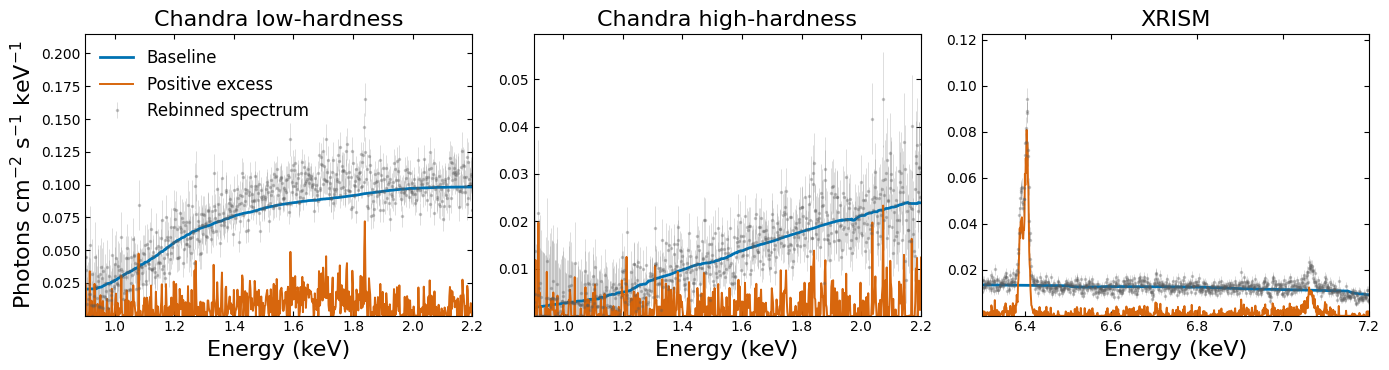

In [6]:
# ============================================================
# Load and rebin Vela X-1 spectra
# ============================================================
# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

BLISS_DIR = Path("/Users/graciela/Desktop/git/BLiSS")
NOTEBOOKS_DIR = BLISS_DIR / "notebooks"

vela_paths = {
    "Chandra high-hardness": NOTEBOOKS_DIR /  "spec_chh.dat",
    "Chandra low-hardness":  NOTEBOOKS_DIR / "spec_chl.dat",
    "XRISM":                 NOTEBOOKS_DIR /  "spec_xr.dat",
}

# ------------------------------------------------------------
# Rebinning values
# ------------------------------------------------------------

rebin_values = {
    "Chandra high-hardness": 0.002,
    "Chandra low-hardness":  0.002,
    "XRISM":                 0.001,
}

# ------------------------------------------------------------
# Load, clean, sort and rebin
# ------------------------------------------------------------

vela_spectra = {}

for name, path in vela_paths.items():

    loaded = load_text_spectrum(path)

    energy = np.asarray(loaded[0], dtype=float)
    values = np.asarray(loaded[1], dtype=float)
    errors = np.asarray(loaded[2], dtype=float)

    valid = (
        np.isfinite(energy)
        & np.isfinite(values)
        & np.isfinite(errors)
        & (errors > 0)
    )

    energy = energy[valid]
    values = values[valid]
    errors = errors[valid]

    order = np.argsort(energy)
    
    energy = energy[order]
    values = values[order]
    errors = errors[order]

    resolution = rebin_values[name]

    energy, values, errors = rebin_resolution(
        energy,
        values,
        errors,
        resolution,
    )

    #energy, values, errors = rebin_snr(energy,values,errors,3,)

    #plt.plot(energy, values,".")
    #plt.show()

    bin_width = np.full_like(energy, resolution, dtype=float)

    vela_spectra[name] = {
        "energy": energy,
        "values": values,
        "errors": errors,
        "bin_width": bin_width,
        "path": path,
        "rebin_resolution": resolution,
    }

    print(f"{name}: {len(energy)} bins, rebin = {resolution:.4f} keV")


# ============================================================
# Plot: spectrum + baseline + positive excess
# ============================================================

figures_dir = NOTEBOOKS_DIR / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

plot_colors = {
    "spectrum": "#5A5A5A",   # neutral grey
    "baseline": "#0072B2",   # deep blue
    "excess":   "#D55E00",   # vermillion/orange
}


plot_order = [
    "Chandra low-hardness",
    "Chandra high-hardness",
    "XRISM",
]


panel_labels = ["(a)", "(b)", "(c)"]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 3.8),
    sharey=False,
)

k=0
for ax, name, panel_label in zip(axes, plot_order, panel_labels):

    spec = vela_spectra[name]

    energy = np.asarray(spec["energy"], dtype=float)
    values = np.asarray(spec["values"], dtype=float)
    errors = np.asarray(spec["errors"], dtype=float)

    # --------------------------------------------------------
    # Baseline and positive excess
    # --------------------------------------------------------

    baseline = base_calculator(values)

    residuals = values - baseline
    ylines = np.maximum(residuals, 0.0)

    # Save back into dictionary
    vela_spectra[name]["energy"] = energy
    vela_spectra[name]["values"] = values
    vela_spectra[name]["errors"] = errors
    vela_spectra[name]["baseline"] = baseline
    vela_spectra[name]["residuals"] = residuals
    vela_spectra[name]["ylines"] = ylines

    # --------------------------------------------------------
    # Plot spectrum
    # --------------------------------------------------------

    ax.errorbar(
        energy,
        values,
        yerr=errors,
        fmt=".",
        markersize=3,
        linewidth=0.6,
        elinewidth=0.5,
        alpha=0.28,
        color=plot_colors["spectrum"],
        ecolor=plot_colors["spectrum"],
        label="Rebinned spectrum",
    )
    
    ax.plot(
        energy,
        baseline,
        linewidth=2.0,
        color=plot_colors["baseline"],
        label="Baseline",
    )
    
    ax.plot(
        energy,
        ylines,
        linewidth=1.4,
        alpha=0.95,
        color=plot_colors["excess"],
        label="Positive excess")

    # Panel label
    #ax.text( 0.03,0.93,panel_label,transform=ax.transAxes,fontsize=12,fontweight="bold",va="top",)

    ax.set_title(name, fontsize=16)
    ax.set_xlabel("Energy (keV)", fontsize=16)
    ax.tick_params(direction="in", top=True, right=True)



    xmin=0.9
    xmax=2.2

    if k==2:
        xmin=6.3
        xmax=7.2

    ymax = np.nanmax(values[(energy>xmin)& (energy<xmax)])


    if np.isfinite(ymax) and ymax > 0:
        ax.set_ylim(0.0001, 1.3 * ymax)

    ax.set_xlim(xmin, xmax)
    k=k+1
    #ax.set_yscale("log")
    #ax.set_xscale("log")


axes[0].set_ylabel(r"Photons cm$^{-2}$ s$^{-1}$ keV$^{-1}$", fontsize=16)

axes[0].legend(
    loc="best",
    fontsize=12,
    frameon=False,
)

plt.tight_layout()

fig.savefig(
    figures_dir / "vela_x1_baseline_row.pdf",
    bbox_inches="tight",
)

fig.savefig(
    figures_dir / "vela_x1_baseline_row.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Candidate lines before global fit

In [7]:
# ============================================================
# CANDIDATE LINES
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

from bliss import find_candidate_lines

# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------

outdir = Path("vela_line_search_results")
outdir.mkdir(exist_ok=True)

# ------------------------------------------------------------
# Container
# ------------------------------------------------------------

vela_candidate_lines = {}
vela_run_times = {}

# ------------------------------------------------------------
# Energy ranges for candidate search
# ------------------------------------------------------------

search_ranges = {
    "Chandra high-hardness": (0.7, 2.2),
    "Chandra low-hardness":  (0.7, 2.2),
    "XRISM":                 (6.0, 7.2),
}

# ------------------------------------------------------------
# Run BLiSS candidate search spectrum by spectrum
# ------------------------------------------------------------

for name, spec in vela_spectra.items():

    print(f"\n{name}")
    print("-" * len(name))

    energy = np.asarray(spec["energy"], dtype=float)
    values = np.asarray(spec["values"], dtype=float)
    errors = np.asarray(spec["errors"], dtype=float)

    en1, en2 = search_ranges[name]

    # --------------------------------------------------------
    # BLiSS candidate search
    # --------------------------------------------------------

    safe_name = name.replace(" ", "_").replace("-", "_").lower()

    this_outdir = outdir / safe_name
    this_outdir.mkdir(parents=True, exist_ok=True)

    t0 = time.perf_counter()

    candidate_lines = find_candidate_lines(
        energy,
        values,
        errors,
        en1=en1,
        en2=en2,
        output_dir=this_outdir,
    )

    t1 = time.perf_counter()
    elapsed = t1 - t0

    vela_run_times[name] = elapsed
    vela_candidate_lines[name] = candidate_lines
    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    candidate_lines.to_csv(
        outdir / f"{safe_name}_candidate_lines.csv",
        index=False,
    )

    print(f"Search range: {en1:.2f}--{en2:.2f} keV")
    print(f"Number of bins: {len(energy)}")
    print(f"Number of candidate lines: {len(candidate_lines)}")

    display(candidate_lines.head())


Chandra high-hardness
---------------------
Search range: 0.70--2.20 keV
Number of bins: 5911
Number of candidate lines: 89


,center,ecenter,sigma,esigma,amplitude,eamplitude,relative_power,noise_on_block,value_on_line,base_on_line,snr_peak,snr_amplitude,area,earea,snr_area,ew,cluster_probability
0,0.773206,0.663269,0.000474,111.583820,0.040280,42234.948510,0.760537,0.020274,0.005057,0.000688,1.986816,9.537189e-07,0.000048,51.445005,9.305677e-07,69.604722,0.0
1,0.891207,0.739095,0.000483,211.304532,0.026805,50222.018551,0.477843,0.016988,0.004884,0.001726,1.577906,5.337343e-07,0.000032,62.466332,5.197655e-07,18.815804,0.0
2,0.905365,32.830885,0.000467,48.910298,0.060419,28286.709434,0.766844,0.015918,0.013646,0.001801,3.795561,2.135961e-06,0.000071,33.933740,2.084450e-06,39.278768,0.0
3,0.916343,0.000401,0.001041,0.000225,0.019919,0.003420,0.834660,0.014735,0.021719,0.001957,1.351836,5.824235e+00,0.000052,0.000014,3.619161e+00,26.562485,1.0
4,0.959088,10.652271,0.000505,22.376842,0.016575,2831.415914,0.433266,0.012224,0.006029,0.002384,1.355950,5.853831e-06,0.000021,3.704762,5.666522e-06,8.805573,0.0



Chandra low-hardness
--------------------
Search range: 0.70--2.20 keV
Number of bins: 5811
Number of candidate lines: 121


,center,ecenter,sigma,esigma,amplitude,eamplitude,relative_power,noise_on_block,value_on_line,base_on_line,snr_peak,snr_amplitude,area,earea,snr_area,ew,cluster_probability
0,0.794712,3.214530,0.000485,83.766090,0.300077,220005.749132,0.686998,0.186388,0.045854,0.008508,1.609959,1.363951e-06,0.000365,274.852084,1.327628e-06,42.890835,0.24
1,0.822712,9.699610,0.000494,243.660336,0.092208,186760.595508,0.316942,0.095273,0.025589,0.013272,0.967828,4.937228e-07,0.000114,238.011312,4.797026e-07,8.602358,0.24
2,0.839923,40017.254348,0.000263,52366.783912,0.028021,358.025410,0.399259,0.070432,0.036664,0.015741,0.397845,7.826522e-05,0.000019,3678.142042,5.031302e-09,1.175640,0.44
3,0.848780,20.822317,0.000474,84.605668,0.195436,154475.732104,0.415749,0.057792,0.046373,0.019137,3.381721,1.265159e-06,0.000232,188.235304,1.234109e-06,12.138809,0.24
4,0.856697,24.330723,0.000486,243.668338,0.058259,123800.100312,0.167168,0.049483,0.027038,0.019293,1.177352,4.705909e-07,0.000071,154.896062,4.580050e-07,3.677189,0.24



XRISM
-----
Search range: 6.00--7.20 keV
Number of bins: 18012
Number of candidate lines: 168


,center,ecenter,sigma,esigma,amplitude,eamplitude,relative_power,noise_on_block,value_on_line,base_on_line,snr_peak,snr_amplitude,area,earea,snr_area,ew,cluster_probability
0,6.019153,0.000488,0.001318,0.000488,0.002943,0.000944,0.062497,0.001827,0.014357,0.012668,1.610877,3.117912,0.000010,0.000005,2.040240,0.767459,0.09
1,6.031026,2.453185,0.000246,25.237081,0.016248,6920.996304,0.082018,0.001808,0.014864,0.012611,8.984240,0.000002,0.000010,4.381964,0.000002,0.792979,1.00
2,6.036105,7.036378,0.000254,13.335485,0.014834,2956.557302,0.121226,0.001778,0.016089,0.012610,8.341148,0.000005,0.000009,1.948018,0.000005,0.749564,1.00
3,6.045288,104.254588,0.000211,44.035416,0.008750,7640.657161,0.147381,0.001768,0.016947,0.012593,4.949297,0.000001,0.000005,4.163570,0.000001,0.368279,1.00
4,6.053488,0.001330,0.000696,0.001034,0.002267,0.003158,0.074085,0.001740,0.014639,0.012620,1.302872,0.717661,0.000004,0.000008,0.491109,0.313562,0.09


In [8]:
vela_run_times

{'Chandra high-hardness': 8.685808583002654,
 'Chandra low-hardness': 22.257947000005515,
 'XRISM': 14.030002416999196}

## Compare candidate lines with Victoria's paper within each energy window. 

In [9]:
# ------------------------------------------------------------
# Compare BLiSS with Victoria
# ------------------------------------------------------------

victoria_chandra_candidate_matches = match_victoria_to_candidate_lines_current_run( victoria_lines=victoria_lines, 
                                                                                   vela_candidate_lines=vela_candidate_lines, 
                                                                                   energy_windows=energy_windows_first3, 
                                                                                   obs_pairs=obs_pairs, tolerance_eV=15.0, )

m = victoria_chandra_candidate_matches.copy()

# Make sure the match column is boolean
m["match_within_tolerance"] = (
    m["match_within_tolerance"]
    .fillna(False)
    .astype(bool))

summary_chandra_first3 = (
    m
    .groupby(
        ["victoria_observation", "our_observation", "window"],
        dropna=False,
    )
    .agg(
        n_recovered=("match_within_tolerance", "sum"),
        n_victoria_lines=("match_within_tolerance", "size"),
    )
    .reset_index()
)

summary_chandra_first3["n_missing"] = (
    summary_chandra_first3["n_victoria_lines"]
    - summary_chandra_first3["n_recovered"]
)

summary_chandra_first3["fraction_recovered"] = (
    summary_chandra_first3["n_recovered"]
    / summary_chandra_first3["n_victoria_lines"]
)

display(summary_chandra_first3)

,victoria_observation,our_observation,window,n_recovered,n_victoria_lines,n_missing,fraction_recovered
0,Chandra high-hardness,Chandra high-hardness,mg_1p25_1p55keV,4,4,0,1.0
1,Chandra high-hardness,Chandra high-hardness,ne_0p90_1p25keV,5,5,0,1.0
2,Chandra high-hardness,Chandra high-hardness,si_1p65_2p15keV,6,6,0,1.0
3,Chandra low-hardness,Chandra low-hardness,mg_1p25_1p55keV,3,3,0,1.0
4,Chandra low-hardness,Chandra low-hardness,ne_0p90_1p25keV,4,4,0,1.0
5,Chandra low-hardness,Chandra low-hardness,si_1p65_2p15keV,2,2,0,1.0


In [10]:
m

,victoria_observation,our_observation,window,window_emin_keV,window_emax_keV,element,line_id,line_type,lambda_obs_A,energy_victoria_keV,...,delta_E_keV,delta_E_eV,delta_v_km_s,candidate_amplitude,candidate_sigma,candidate_snr_peak,candidate_snr_amplitude,candidate_snr_area,candidate_cluster_probability,candidate_relative_power
0,Chandra high-hardness,Chandra high-hardness,mg_1p25_1p55keV,1.25,1.55,Mg,Mg XI f,emission,9.3189,1.330460,...,0.000959,0.959236,216.144686,0.027919,0.000490,7.894448,2.905161e-06,2.815574e-06,1.00,0.319112
1,Chandra high-hardness,Chandra high-hardness,mg_1p25_1p55keV,1.25,1.55,Mg,Mg XI i,emission,9.2342,1.342663,...,-0.003314,-3.313851,-739.923060,0.016120,0.000490,4.677278,2.695969e-06,2.618915e-06,1.00,0.169682
2,Chandra high-hardness,Chandra high-hardness,mg_1p25_1p55keV,1.25,1.55,Mg,Mg XI r,emission,9.1732,1.351592,...,0.001636,1.635607,362.789085,0.052083,0.000480,14.528472,6.543109e-07,6.379313e-07,1.00,0.266179
3,Chandra high-hardness,Chandra high-hardness,mg_1p25_1p55keV,1.25,1.55,Mg,Mg XII Lyα,emission,8.4249,1.471640,...,0.001569,1.569003,319.626615,0.067844,0.000495,17.221841,5.600851e-06,5.435651e-06,1.00,0.289794
4,Chandra high-hardness,Chandra high-hardness,ne_0p90_1p25keV,0.90,1.25,Ne,Ne IX f,emission,13.6893,0.905702,...,-0.000337,-0.336892,-111.513172,0.060419,0.000467,3.795561,2.135961e-06,2.084450e-06,0.00,0.766844
5,Chandra high-hardness,Chandra high-hardness,ne_0p90_1p25keV,0.90,1.25,Ne,Ne IX i,emission,13.5421,0.915546,...,0.000797,0.797075,260.999400,0.019919,0.001041,1.351836,5.824235e+00,3.619161e+00,1.00,0.834660
6,Chandra high-hardness,Chandra high-hardness,ne_0p90_1p25keV,0.90,1.25,Ne,Ne IX r,emission,13.4377,0.922659,...,-0.006316,-6.315975,-2052.200248,0.019919,0.001041,1.351836,5.824235e+00,3.619161e+00,1.00,0.834660
7,Chandra high-hardness,Chandra high-hardness,ne_0p90_1p25keV,0.90,1.25,Ne,Ne X Lyα,emission,12.1249,1.022559,...,-0.000702,-0.701998,-205.810963,0.005067,0.002439,0.554360,3.122111e+00,2.024778e+00,0.00,0.490078
8,Chandra high-hardness,Chandra high-hardness,ne_0p90_1p25keV,0.90,1.25,Ne,Ne X Lyβ,emission,10.2314,1.211801,...,-0.000376,-0.375664,-92.936959,0.050452,0.000467,11.880014,4.201381e-06,4.094844e-06,1.00,0.544569
9,Chandra high-hardness,Chandra high-hardness,si_1p65_2p15keV,1.65,2.15,Si,Si II–VI Kα blend,emission,7.1011,1.745986,...,0.000844,0.843712,144.868546,0.008307,0.002901,1.945197,4.446362e+00,2.895824e+00,1.00,0.157931


## Filt lines by cluster prob and snr's. Produce a global fit

In [11]:
# ============================================================
# Filter candidate lines + Victoria matches + global fit
# ============================================================

# ============================================================
# Energy windows
# ============================================================

energy_windows_victoria = {
    "ne_0p90_1p25keV": (0.90, 1.25),
    "mg_1p25_1p55keV": (1.25, 1.55),
    "si_1p65_2p15keV": (1.65, 2.15),
    "fe_6p0_7p5keV":   (6.20, 7.20),
}


# ============================================================
# Filtering configuration
# ============================================================

FILTER_CONFIGS = {
    "victoria": {  # Chandra / Victoria
        "P_MIN": 1,
        "REL_POWER_MIN": 0.1,
        "SNR_PEAK_MIN": 10,
        "SNR_AREA_MIN": 10,
        "SNR_AMPLITUDE_MIN": 10,
    },
    "camille": {  # XRISM / Camille
        "P_MIN": 1,
        "REL_POWER_MIN": 0.1,
        "SNR_PEAK_MIN": 10,
        "SNR_AREA_MIN": 10,
        "SNR_AMPLITUDE_MIN": 10,
    },
}

ION_VMAX = 1000

# This tolerance is only used to recover the exact candidate row from
# vela_candidate_lines, after Victoria has already been matched.
VICTORIA_CENTER_JOIN_TOL_KEV = 1e-5


def get_filter_config(name):
    """Return filtering thresholds for each dataset."""

    if name == "XRISM":
        return FILTER_CONFIGS["camille"]

    return FILTER_CONFIGS["victoria"]


# ============================================================
# Output folder and containers
# ============================================================

outdir = Path("vela_line_search_results_windows")
outdir.mkdir(exist_ok=True)

vela_window_clean_lines = {}
vela_window_global_lines = {}
vela_window_yfit = {}
vela_window_baselines = {}


# ============================================================
# Make Victoria match table if it does not already exist
# ============================================================

if "victoria_chandra_candidate_matches" not in globals():

    victoria_chandra_candidate_matches = match_victoria_to_candidate_lines_current_run(
        victoria_lines=victoria_lines,
        vela_candidate_lines=vela_candidate_lines,
        energy_windows=energy_windows_first3,
        obs_pairs=obs_pairs,
        tolerance_eV=20.0,
    )


# ============================================================
# Helper functions
# ============================================================

def as_bool(x):
    """Robust conversion to bool for match columns."""

    if isinstance(x, str):
        return x.strip().lower() in ["true", "yes", "y", "1"]

    if pd.isna(x):
        return False

    return bool(x)


def filter_candidate_lines(df, emin=None, emax=None, config=None):
    """Filter already-detected BLiSS candidates."""

    if df is None or len(df) == 0:
        return pd.DataFrame()

    if config is None:
        config = FILTER_CONFIGS["victoria"]

    df = df.copy()

    required = [
        "center",
        "cluster_probability",
        "snr_peak",
        "snr_area",
        "snr_amplitude",
        "relative_power",
    ]

    missing = [col for col in required if col not in df.columns]

    if missing:
        print(f"Missing columns: {missing}")
        return pd.DataFrame()

    for col in required:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    mask = (
        np.isfinite(df["center"])
        & (df["cluster_probability"] >= config["P_MIN"])
        & (
            (df["snr_peak"] >= config["SNR_PEAK_MIN"])
            | (df["snr_area"] >= config["SNR_AREA_MIN"])
            | (df["snr_amplitude"] >= config["SNR_AMPLITUDE_MIN"])
        )
        & (df["relative_power"] >= config["REL_POWER_MIN"])
    )

    if emin is not None:
        mask &= df["center"] >= emin

    if emax is not None:
        mask &= df["center"] <= emax

    out = df.loc[mask].copy()
    out["selection_source"] = "filter"
    out["victoria_match"] = False
    out["victoria_line_id"] = "--"

    return out.sort_values("center").reset_index(drop=True)


def add_victoria_matches_to_clean_lines(
    clean_lines,
    candidates,
    matches,
    observation,
    window_name,
    tol_keV=1e-5,
):
    """
    Add BLiSS candidates matched to Victoria lines, even if they did not pass
    the normal filter.
    """

    if clean_lines is None:
        clean_lines = pd.DataFrame()

    clean_lines = clean_lines.copy()

    if candidates is None or len(candidates) == 0:
        return clean_lines

    if matches is None or len(matches) == 0:
        return clean_lines

    if "center" not in candidates.columns:
        return clean_lines

    required_match_cols = [
        "our_observation",
        "window",
        "match_within_tolerance",
        "candidate_center_keV",
        "line_id",
    ]

    missing = [c for c in required_match_cols if c not in matches.columns]

    if missing:
        print(f"Missing columns in Victoria match table: {missing}")
        return clean_lines

    m = matches[
        (matches["our_observation"] == observation)
        & (matches["window"] == window_name)
        & (matches["match_within_tolerance"].apply(as_bool))
    ].copy()

    if len(m) == 0:
        return clean_lines

    m["candidate_center_keV"] = pd.to_numeric(
        m["candidate_center_keV"],
        errors="coerce",
    )

    m = m[np.isfinite(m["candidate_center_keV"])].copy()

    if len(m) == 0:
        return clean_lines

    candidates = candidates.copy()
    candidates["center"] = pd.to_numeric(
        candidates["center"],
        errors="coerce",
    )
    candidates = candidates[np.isfinite(candidates["center"])].copy()

    if len(candidates) == 0:
        return clean_lines

    forced_rows = []

    for _, row in m.iterrows():

        c = row["candidate_center_keV"]

        delta = np.abs(candidates["center"] - c)

        if len(delta) == 0:
            continue

        idx = delta.idxmin()

        if delta.loc[idx] <= tol_keV:

            forced = candidates.loc[idx].copy()

            forced["selection_source"] = "victoria_match"
            forced["victoria_match"] = True
            forced["victoria_line_id"] = row.get("line_id", "--")

            forced_rows.append(forced)

    if len(forced_rows) == 0:
        return clean_lines

    forced_lines = pd.DataFrame(forced_rows)

    if len(clean_lines) > 0:

        if "selection_source" not in clean_lines.columns:
            clean_lines["selection_source"] = "filter"

        if "victoria_match" not in clean_lines.columns:
            clean_lines["victoria_match"] = False

        if "victoria_line_id" not in clean_lines.columns:
            clean_lines["victoria_line_id"] = "--"

    combined = pd.concat(
        [
            clean_lines,
            forced_lines,
        ],
        ignore_index=True,
    )

    combined["center"] = pd.to_numeric(
        combined["center"],
        errors="coerce",
    )

    combined = combined[np.isfinite(combined["center"])].copy()

    if len(combined) == 0:
        return pd.DataFrame()

    combined["_center_round"] = combined["center"].round(6)

    # --------------------------------------------------------
    # Merge duplicated centers, but keep track of origin.
    # --------------------------------------------------------

    source_by_center = {}

    for c, group in combined.groupby("_center_round"):

        sources = set(
            group["selection_source"]
            .dropna()
            .astype(str)
        )

        if "filter" in sources and "victoria_match" in sources:
            source_by_center[c] = "filter+victoria_match"

        elif "victoria_match" in sources:
            source_by_center[c] = "victoria_match"

        else:
            source_by_center[c] = "filter"

    combined = combined.drop_duplicates(
        "_center_round",
        keep="first",
    ).copy()

    combined["selection_source"] = combined["_center_round"].map(
        source_by_center
    )

    # --------------------------------------------------------
    # Re-mark Victoria matches after removing duplicates.
    # --------------------------------------------------------

    forced_lines["center"] = pd.to_numeric(
        forced_lines["center"],
        errors="coerce",
    )

    victoria_centers = set(
        forced_lines["center"].round(6)
    )

    victoria_labels = {
        round(row["center"], 6): row.get("victoria_line_id", "--")
        for _, row in forced_lines.iterrows()
    }

    combined["victoria_match"] = combined["_center_round"].isin(
        victoria_centers
    )

    combined["victoria_line_id"] = combined["_center_round"].map(
        victoria_labels
    ).fillna("--")

    combined = combined.drop(columns=["_center_round"])

    return combined.sort_values("center").reset_index(drop=True)


# ============================================================
# Run window-by-window global fit
# ============================================================

for name, spec in vela_spectra.items():

    print(f"\n{name}")
    print("=" * len(name))

    filter_config = get_filter_config(name)

    print(
        "Filter:",
        f"P >= {filter_config['P_MIN']},",
        f"relative_power >= {filter_config['REL_POWER_MIN']},",
        "any S/N >=",
        filter_config["SNR_PEAK_MIN"],
    )

    energy_full = np.asarray(spec["energy"], dtype=float)
    values_full = np.asarray(spec["values"], dtype=float)
    errors_full = np.asarray(spec["errors"], dtype=float)

    if "baseline" not in spec:
        raise ValueError(
            f"No baseline found for {name}. "
            "Run the baseline cell first so vela_spectra[name]['baseline'] exists."
        )

    baseline_full = np.asarray(
        spec["baseline"],
        dtype=float,
    )

    valid = (
        np.isfinite(energy_full)
        & np.isfinite(values_full)
        & np.isfinite(errors_full)
        & np.isfinite(baseline_full)
        & (errors_full > 0)
    )

    energy_full = energy_full[valid]
    values_full = values_full[valid]
    errors_full = errors_full[valid]
    baseline_full = baseline_full[valid]

    order = np.argsort(energy_full)

    energy_full = energy_full[order]
    values_full = values_full[order]
    errors_full = errors_full[order]
    baseline_full = baseline_full[order]

    candidates = vela_candidate_lines.get(
        name,
        pd.DataFrame(),
    )

    for window_name, (emin, emax) in energy_windows_victoria.items():

        print(f"\n  {window_name}: {emin:.2f}--{emax:.2f} keV")
        print("  " + "-" * 35)

        key = (name, window_name)

        # ----------------------------------------------------
        # Crop spectrum and stored baseline to this window
        # ----------------------------------------------------

        mask_energy = (
            (energy_full >= emin)
            & (energy_full <= emax)
        )

        energy = energy_full[mask_energy]
        values = values_full[mask_energy]
        errors = errors_full[mask_energy]
        base = baseline_full[mask_energy]

        if len(energy) < 5:

            print("  Not enough bins. Skipping.")

            vela_window_clean_lines[key] = pd.DataFrame()
            vela_window_global_lines[key] = pd.DataFrame()
            vela_window_yfit[key] = np.array([])
            vela_window_baselines[key] = np.array([])

            continue

        residuals = values - base
        ylines = np.maximum(residuals, 0.0)

        vela_window_baselines[key] = base

        # ----------------------------------------------------
        # Filter candidates in this window
        # ----------------------------------------------------

        clean_lines = filter_candidate_lines(
            candidates,
            emin=emin,
            emax=emax,
            config=filter_config,
        )

        # ----------------------------------------------------
        # Add Victoria-matched candidates even if they fail filter
        # ----------------------------------------------------

        clean_lines = add_victoria_matches_to_clean_lines(
            clean_lines=clean_lines,
            candidates=candidates,
            matches=victoria_chandra_candidate_matches,
            observation=name,
            window_name=window_name,
            tol_keV=VICTORIA_CENTER_JOIN_TOL_KEV,
        )

        vela_window_clean_lines[key] = clean_lines

        print(f"  Final candidates for global fit: {len(clean_lines)}")

        if "selection_source" in clean_lines.columns:
            print(clean_lines["selection_source"].value_counts(dropna=False))

        safe_name = name.replace(" ", "_").replace("/", "_")

        this_outdir = outdir / safe_name / window_name
        this_outdir.mkdir(parents=True, exist_ok=True)

        clean_lines.to_csv(
            this_outdir / "clean_candidate_lines_filter_plus_victoria.csv",
            index=False,
        )

        if len(clean_lines) == 0:

            print("  No clean candidates. Skipping global fit.")

            vela_window_global_lines[key] = pd.DataFrame()
            vela_window_yfit[key] = np.zeros_like(energy)

            continue

        # ----------------------------------------------------
        # Global fit using stored baseline
        # ----------------------------------------------------

        result, yfit = fit_global(
            clean_lines,
            energy,
            values,
            errors,
            base=base,
            ylines=ylines,
            show_plot=False,
            output_dir=this_outdir / "global_fit",
            plot_name="global_fit.png",
            save_csv=True,
            return_yfit=True,
        )

        if result is None:
            result = pd.DataFrame()

        if yfit is None or len(yfit) != len(energy):
            yfit = np.zeros_like(energy)

        # ----------------------------------------------------
        # Keep Victoria labels after the global fit
        # ----------------------------------------------------

        if len(result) > 0:

            if "victoria_match" in clean_lines.columns:
                result["victoria_match"] = (
                    clean_lines["victoria_match"]
                    .reset_index(drop=True)
                    .reindex(result.index)
                    .fillna(False)
                    .astype(bool)
                )

            if "victoria_line_id" in clean_lines.columns:
                result["victoria_line_id"] = (
                    clean_lines["victoria_line_id"]
                    .reset_index(drop=True)
                    .reindex(result.index)
                    .fillna("--")
                )

            # Tentative ion identification from the atomic table.
            # This should preserve all existing result columns.
            result = add_most_probable_ion(
                result,
                ION_VMAX,
            )

        vela_window_global_lines[key] = result
        vela_window_yfit[key] = yfit

        result.to_csv(
            this_outdir / "global_fit_lines_identified.csv",
            index=False,
        )

        print(f"  Global fitted lines: {len(result)}")
        display(result.head())


Chandra high-hardness
Filter: P >= 1, relative_power >= 0.1, any S/N >= 10

  ne_0p90_1p25keV: 0.90--1.25 keV
  -----------------------------------
  Final candidates for global fit: 4
selection_source
victoria_match           3
filter+victoria_match    1
Name: count, dtype: int64
  Global fitted lines: 4


,ion,center,ecenter,sigma,esigma,amplitude,eamplitude,relative_power,noise_on_block,value_on_line,...,snr_peak,snr_amplitude,area,earea,snr_area,ew,cluster_probability,fit_error_flag,victoria_match,victoria_line_id
0,ne_viii,0.905366,217.300866,0.000468,322.733778,0.059595,182356.241513,0.766844,0.015918,0.013646,...,3.743801,3.268074e-07,0.000070,219.502865,3.188273e-07,13.154026,0.0,unconstrained,True,Ne IX f
1,ne_viii,0.916342,0.001817,0.001043,0.001027,0.019910,0.016171,0.834660,0.014735,0.021719,...,1.351215,1.231171e+00,0.000052,0.000066,7.834699e-01,24.290571,1.0,,True,Ne IX r
2,ne_ix,1.021821,0.004326,0.002462,0.004287,0.005031,0.007670,0.490078,0.009140,0.008526,...,0.550442,6.559240e-01,0.000031,0.000072,4.320706e-01,10.222801,0.0,unconstrained,True,Ne X Lyα
3,mg_vii,1.211428,38.675255,0.000470,41.080581,0.049154,18475.722196,0.544569,0.004247,0.017716,...,11.574344,2.660468e-06,0.000058,22.337139,2.591264e-06,4.783591,1.0,unconstrained,True,Ne X Lyβ



  mg_1p25_1p55keV: 1.25--1.55 keV
  -----------------------------------
  Final candidates for global fit: 5
selection_source
victoria_match           2
filter+victoria_match    2
filter                   1
Name: count, dtype: int64
  Global fitted lines: 5


,ion,center,ecenter,sigma,esigma,amplitude,eamplitude,relative_power,noise_on_block,value_on_line,...,snr_peak,snr_amplitude,area,earea,snr_area,ew,cluster_probability,fit_error_flag,victoria_match,victoria_line_id
0,mg_x,1.331419,14.867094,0.000490,17.305346,0.027920,3875.418200,0.319112,0.003537,0.016056,...,7.894492,7.204272e-06,0.000034,4.914469,6.982087e-06,1.882015,1.0,unconstrained,True,Mg XI f
1,mg_x,1.339349,43.937141,0.000490,76.172278,0.016105,10239.008000,0.169682,0.003446,0.011910,...,4.672981,1.572890e-06,0.000020,12.948164,1.527891e-06,0.815905,1.0,unconstrained,True,Mg XI i
2,mg_xi,1.353227,12.629101,0.000480,159.107912,0.052083,75729.512800,0.266179,0.003585,0.015007,...,14.528505,6.877477e-07,0.000063,93.417019,6.705302e-07,NaN,1.0,unconstrained,True,Mg XI r
3,mg_xi,1.423084,58.959501,0.000472,114.049072,0.040448,43177.115969,0.259189,0.003494,0.017449,...,11.575803,9.368017e-07,0.000048,52.374465,9.136845e-07,1.398756,1.0,unconstrained,False,--
4,mg_xi,1.473209,0.234607,0.000496,51.481886,0.067512,28149.095237,0.289794,0.003939,0.020266,...,17.137586,2.398359e-06,0.000084,36.054466,2.327287e-06,NaN,1.0,unconstrained,True,Mg XII Lyα



  si_1p65_2p15keV: 1.65--2.15 keV
  -----------------------------------
  Final candidates for global fit: 10
selection_source
victoria_match    6
filter            4
Name: count, dtype: int64
  Global fitted lines: 10


...

,ion,center,ecenter,sigma,esigma,amplitude,eamplitude,relative_power,noise_on_block,value_on_line,...,snr_peak,snr_amplitude,area,earea,snr_area,ew,cluster_probability,fit_error_flag,victoria_match,victoria_line_id
0,mg_x,1.332597,26.009639,0.000479,49.577042,0.205042,90882.320023,0.216202,0.012018,0.109202,...,17.060844,2.256126e-06,0.000246,112.129087,2.197101e-06,1.103572,1.00,unconstrained,True,Mg XI f
1,mg_x,1.344380,0.001029,0.001035,0.001394,0.031378,0.038718,0.151707,0.012639,0.096908,...,2.482597,8.104460e-01,0.000081,0.000149,5.476241e-01,1.093005,0.36,unconstrained,True,Mg XI i
2,mg_xi,1.350429,21.113182,0.000513,18.408466,0.014467,1785.852633,0.037985,0.012639,0.077530,...,1.144598,8.100893e-06,0.000019,2.392280,7.779110e-06,0.157355,0.23,unconstrained,True,Mg XI r
3,mg_ix,1.372734,6.158315,0.000481,163.791076,0.184344,271140.818696,0.130223,0.012148,0.095908,...,15.174637,6.798840e-07,0.000222,335.598143,6.623688e-07,NaN,1.00,unconstrained,False,--
4,fe_xxii,1.532770,33.164919,0.000476,179.975273,0.179837,297026.311182,0.126864,0.009353,0.107907,...,19.227049,6.054575e-07,0.000215,363.876297,5.902166e-07,NaN,1.00,unconstrained,False,--



  si_1p65_2p15keV: 1.65--2.15 keV
  -----------------------------------
  Final candidates for global fit: 9
selection_source
filter            7
victoria_match    2
Name: count, dtype: int64
  Global fitted lines: 9


,ion,center,ecenter,sigma,esigma,amplitude,eamplitude,relative_power,noise_on_block,value_on_line,...,snr_peak,snr_amplitude,area,earea,snr_area,ew,cluster_probability,fit_error_flag,victoria_match,victoria_line_id
0,si_viii,1.686321,0.005452,0.000728,0.004952,0.047812,5.169744e-01,0.161274,0.010119,0.122484,...,4.725163,9.248474e-02,0.000087,0.001114,7.827311e-02,0.939107,1.0,unconstrained,False,--
1,si_v,1.730777,1.404366,0.000532,6.753756,0.134819,5.906631e+03,0.139753,0.012036,0.118761,...,11.201069,2.282509e-05,0.000180,8.207424,2.192478e-05,1.088954,1.0,unconstrained,False,--
2,si_vii,1.755003,1874.431015,0.000419,1353.064455,0.105603,1.761576e+06,0.175219,0.011237,0.128668,...,9.397892,5.994800e-08,0.000111,1884.371251,5.885516e-08,0.856882,1.0,unconstrained,False,--
3,si_viii,1.768383,0.003231,0.012815,0.003027,0.020804,4.479861e-03,0.099152,0.011237,0.110455,...,1.851376,4.643824e+00,0.000668,0.000214,3.128797e+00,7.648508,1.0,,True,unidentified 7.022 Å
4,si_x,1.798678,8.378828,0.000487,51.778630,0.228714,1.021789e+05,0.157719,0.009246,0.125893,...,24.737121,2.238366e-06,0.000279,128.273920,2.177605e-06,0.748829,1.0,unconstrained,False,--



  fe_6p0_7p5keV: 6.20--7.20 keV
  -----------------------------------
  Final candidates for global fit: 0
Series([], Name: count, dtype: int64)
  No clean candidates. Skipping global fit.

XRISM
=====
Filter: P >= 1, relative_power >= 0.1, any S/N >= 10

  ne_0p90_1p25keV: 0.90--1.25 keV
  -----------------------------------
  Final candidates for global fit: 0
Series([], Name: count, dtype: int64)
  No clean candidates. Skipping global fit.

  mg_1p25_1p55keV: 1.25--1.55 keV
  -----------------------------------
  Final candidates for global fit: 0
Series([], Name: count, dtype: int64)
  No clean candidates. Skipping global fit.

  si_1p65_2p15keV: 1.65--2.15 keV
  -----------------------------------
  Final candidates for global fit: 0
Series([], Name: count, dtype: int64)
  No clean candidates. Skipping global fit.

  fe_6p0_7p5keV: 6.20--7.20 keV
  -----------------------------------
  Final candidates for global fit: 12
selection_source
filter    12
Name: count, dtype: int64
  G

,ion,center,ecenter,sigma,esigma,amplitude,eamplitude,relative_power,noise_on_block,value_on_line,...,snr_peak,snr_amplitude,area,earea,snr_area,ew,cluster_probability,fit_error_flag,victoria_match,victoria_line_id
0,fe_xx,6.267963,63.435733,0.000231,98.368331,0.019679,38339.864765,0.117866,0.001858,0.017134,...,10.590631,5.132780e-07,0.000011,22.733120,5.014493e-07,0.267230,1.0,unconstrained,False,--
1,fe_xxi,6.322020,1.019611,0.000258,7.713824,0.026337,2967.426476,0.144961,0.001883,0.017938,...,13.986083,8.875319e-06,0.000017,1.982777,8.577605e-06,0.339100,1.0,unconstrained,False,--
2,fe_x,6.390474,0.000343,0.004749,0.000276,0.040360,0.001515,0.608945,0.002968,0.054639,...,13.599615,2.663765e+01,0.000480,0.000033,1.444218e+01,46.319590,1.0,,False,--
3,fe_x,6.403939,0.000195,0.004450,0.000157,0.073756,0.001924,0.752976,0.002968,0.094097,...,24.852803,3.832914e+01,0.000823,0.000036,2.281243e+01,65.479451,1.0,,False,--
4,fe_xxv,6.714129,31.158063,0.000232,39.466865,0.024565,18681.320686,0.172061,0.001812,0.017856,...,13.555320,1.314941e-06,0.000014,11.147694,1.283316e-06,0.415636,1.0,unconstrained,False,--


In [12]:
# ============================================================
# Combined LaTeX table: Chandra high/low hardness
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

tables_dir = Path("vela_line_search_results_windows") / "latex_tables"
tables_dir.mkdir(parents=True, exist_ok=True)


def latex_escape_text(x):
    """Escape text for LaTeX and format common line labels."""

    if pd.isna(x):
        return "--"

    x = str(x).strip()

    if x == "" or x.lower() in ["nan", "none"]:
        return "--"

    replacements = {
        "_": r"\_",
        "%": r"\%",
        "&": r"\&",
        "#": r"\#",
        "α": r"$\alpha$",
        "β": r"$\beta$",
        "Lyalpha": r"Ly$\alpha$",
        "Lybeta": r"Ly$\beta$",
        "Lyα": r"Ly$\alpha$",
        "Lyβ": r"Ly$\beta$",
        "Kα": r"K$\alpha$",
        "Kβ": r"K$\beta$",
    }

    for old, new in replacements.items():
        x = x.replace(old, new)

    return x


def format_number(x, ndigits=2):
    x = pd.to_numeric(x, errors="coerce")

    if not np.isfinite(x):
        return "--"

    return f"{x:.{ndigits}f}"


def format_pm_or_sim(
    value,
    error,
    *,
    scale=1.0,
    ndigits=2,
    error_flag=None,
    large_error_ratio=1.0,
):
    """Format value +/- error, or ~value if the error is too large."""

    value = pd.to_numeric(value, errors="coerce")
    error = pd.to_numeric(error, errors="coerce")

    if not np.isfinite(value):
        return "--"

    value_scaled = value * scale
    value_str = format_number(value_scaled, ndigits=ndigits)

    unconstrained = (
        isinstance(error_flag, str)
        and error_flag.strip().lower() == "unconstrained"
    )

    if not np.isfinite(error):
        return rf"$\sim {value_str}$"

    error_scaled = error * scale

    too_large = (
        unconstrained
        or not np.isfinite(error_scaled)
        or error_scaled <= 0
        or abs(error_scaled) > large_error_ratio * max(abs(value_scaled), 1e-30)
    )

    if too_large:
        return rf"$\sim {value_str}$"

    error_str = format_number(error_scaled, ndigits=ndigits)

    return rf"${value_str} \pm {error_str}$"


def get_identification_values(df):
    """Use Victoria label when available, otherwise BLiSS tentative ion."""

    if "ion" in df.columns:
        ion_values = df["ion"].copy()
    elif "most_probable_ion" in df.columns:
        ion_values = df["most_probable_ion"].copy()
    else:
        ion_values = pd.Series(["--"] * len(df), index=df.index)

    if "victoria_match" in df.columns and "victoria_line_id" in df.columns:

        victoria_mask = (
            df["victoria_match"].fillna(False).astype(bool)
            & df["victoria_line_id"].notna()
            & (df["victoria_line_id"].astype(str).str.strip() != "")
            & (df["victoria_line_id"].astype(str).str.strip() != "--")
        )

        ion_values.loc[victoria_mask] = df.loc[
            victoria_mask,
            "victoria_line_id",
        ]

    return ion_values


def rows_for_table(df):
    """Convert one global-fit DataFrame into formatted table rows."""

    if df is None or len(df) == 0:
        return []

    required = [
        "center",
        "ecenter",
        "sigma",
        "esigma",
        "area",
        "earea",
        "snr_peak",
        "relative_power",
        "cluster_probability",
    ]

    missing = [col for col in required if col not in df.columns]

    if missing:
        print(f"Skipping table rows: missing {missing}")
        return []

    df = df.copy()
    ion_values = get_identification_values(df)

    if "fit_error_flag" in df.columns:
        error_flags = df["fit_error_flag"]
    else:
        error_flags = pd.Series([""] * len(df), index=df.index)

    rows = []

    for (_, row), ion, error_flag in zip(df.iterrows(), ion_values, error_flags):

        rows.append(
            [
                format_pm_or_sim(
                    row["center"],
                    row["ecenter"],
                    ndigits=2,
                    error_flag=error_flag,
                ),
                format_pm_or_sim(
                    row["sigma"],
                    row["esigma"],
                    scale=1e3,
                    ndigits=2,
                    error_flag=error_flag,
                ),
                format_pm_or_sim(
                    row["area"],
                    row["earea"],
                    scale=1e4,
                    ndigits=2,
                    error_flag=error_flag,
                ),
                format_number(
                    row["snr_peak"],
                    ndigits=2,
                ),
                format_number(
                    row["relative_power"],
                    ndigits=2,
                ),
                format_number(
                    row["cluster_probability"],
                    ndigits=2,
                ),
                latex_escape_text(ion),
            ]
        )

    return rows


# ============================================================
# Table sections
# ============================================================

table_specs = [
    (
        r"High hardness, Ne region (0.90--1.25 keV)",
        "Chandra high-hardness",
        "ne_0p90_1p25keV",
    ),
    (
        r"High hardness, Mg region (1.25--1.55 keV)",
        "Chandra high-hardness",
        "mg_1p25_1p55keV",
    ),
    (
        r"High hardness, Si region (1.65--2.15 keV)",
        "Chandra high-hardness",
        "si_1p65_2p15keV",
    ),
    (
        r"Low hardness, Ne region (0.90--1.25 keV)",
        "Chandra low-hardness",
        "ne_0p90_1p25keV",
    ),
    (
        r"Low hardness, Mg region (1.25--1.55 keV)",
        "Chandra low-hardness",
        "mg_1p25_1p55keV",
    ),
    (
        r"Low hardness, Si region (1.65--2.15 keV)",
        "Chandra low-hardness",
        "si_1p65_2p15keV",
    ),
]


# ============================================================
# Build LaTeX table manually
# ============================================================

header = [
    r"$E_{\rm c}$ (keV)",
    r"$\sigma$ ($10^{-3}$ keV)",
    r"Area ($10^{-4}$)",
    r"S/N$_{\rm peak}$",
    r"Rel. power",
    r"$P_{\rm BLiSS}$",
    r"ID",
]

ncols = len(header)

table_lines = []

table_lines.append(r"\begin{tabular}{ccccccc}")
table_lines.append(r"\hline")
table_lines.append(" & ".join(header) + r" \\")
table_lines.append(r"\hline")

has_any_rows = False

for section_label, obs_name, window_name in table_specs:

    key = (obs_name, window_name)
    df = vela_window_global_lines.get(key, pd.DataFrame())

    rows = rows_for_table(df)

    if len(rows) == 0:
        continue

    has_any_rows = True

    table_lines.append(
        rf"\multicolumn{{{ncols}}}{{l}}{{\textbf{{{section_label}}}}} \\"
    )
    table_lines.append(r"\hline")

    for row in rows:
        table_lines.append(" & ".join(row) + r" \\")

    table_lines.append(r"\hline")

table_lines.append(r"\end{tabular}")

if not has_any_rows:
    print("No rows available for the combined LaTeX table.")

else:

    latex_body = "\n".join(table_lines)

    latex_table = rf"""
\begin{{table*}}
\centering
\caption{{Global-fit BLiSS line parameters for the Chandra high- and low-hardness Vela X-1 spectra.}}
\label{{tab:vela_x1_chandra_global_fit_lines}}
\begin{{small}}
{latex_body}
\end{{small}}
\end{{table*}}
""".strip()

    tex_path = tables_dir / "vela_x1_chandra_high_low_hardness_global_fit_table.tex"
    tex_path.write_text(latex_table)

    print(f"Saved: {tex_path}")
    print()
    print(latex_table)

Saved: vela_line_search_results_windows/latex_tables/vela_x1_chandra_high_low_hardness_global_fit_table.tex

\begin{table*}
\centering
\caption{Global-fit BLiSS line parameters for the Chandra high- and low-hardness Vela X-1 spectra.}
\label{tab:vela_x1_chandra_global_fit_lines}
\begin{small}
\begin{tabular}{ccccccc}
\hline
$E_{\rm c}$ (keV) & $\sigma$ ($10^{-3}$ keV) & Area ($10^{-4}$) & S/N$_{\rm peak}$ & Rel. power & $P_{\rm BLiSS}$ & ID \\
\hline
\multicolumn{7}{l}{\textbf{High hardness, Ne region (0.90--1.25 keV)}} \\
\hline
$\sim 0.91$ & $\sim 0.47$ & $\sim 0.70$ & 3.74 & 0.77 & 0.00 & Ne IX f \\
$0.92 \pm 0.00$ & $1.04 \pm 1.03$ & $\sim 0.52$ & 1.35 & 0.83 & 1.00 & Ne IX r \\
$\sim 1.02$ & $\sim 2.46$ & $\sim 0.31$ & 0.55 & 0.49 & 0.00 & Ne X Ly$\alpha$ \\
$\sim 1.21$ & $\sim 0.47$ & $\sim 0.58$ & 11.57 & 0.54 & 1.00 & Ne X Ly$\beta$ \\
\hline
\multicolumn{7}{l}{\textbf{High hardness, Mg region (1.25--1.55 keV)}} \\
\hline
$\sim 1.33$ & $\sim 0.49$ & $\sim 0.34$ & 7.89 & 0.32 & 

In [16]:
# ============================================================
# LaTeX table: XRISM
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

tables_dir = Path("vela_line_search_results_windows") / "latex_tables"
tables_dir.mkdir(parents=True, exist_ok=True)


# Reuse your helper functions:
# latex_escape_text
# format_number
# format_pm_or_sim
# get_identification_values
# rows_for_table


table_specs_xrism = [
    (
        r"XRISM, Fe region (6.0--7.5 keV)",
        "XRISM",
        "fe_6p0_7p5keV",
    ),
]

header = [
    r"$E_{\rm c}$ (keV)",
    r"$\sigma$ ($10^{-3}$ keV)",
    r"Area ($10^{-4}$)",
    r"S/N$_{\rm peak}$",
    r"Rel. power",
    r"$P_{\rm BLiSS}$",
    r"ID",
]

ncols = len(header)

table_lines = []

table_lines.append(r"\begin{tabular}{ccccccc}")
table_lines.append(r"\hline")
table_lines.append(" & ".join(header) + r" \\")
table_lines.append(r"\hline")

has_any_rows = False

for section_label, obs_name, window_name in table_specs_xrism:

    key = (obs_name, window_name)
    df = vela_window_global_lines.get(key, pd.DataFrame())

    rows = rows_for_table(df)

    if len(rows) == 0:
        continue

    has_any_rows = True

    table_lines.append(
        rf"\multicolumn{{{ncols}}}{{l}}{{\textbf{{{section_label}}}}} \\"
    )
    table_lines.append(r"\hline")

    for row in rows:
        table_lines.append(" & ".join(row) + r" \\")

    table_lines.append(r"\hline")

table_lines.append(r"\end{tabular}")

if not has_any_rows:
    print("No rows available for the XRISM LaTeX table.")

else:

    latex_body = "\n".join(table_lines)

    latex_table = rf"""
\begin{{table*}}
\centering
\caption{{Global-fit BLiSS line parameters for the XRISM Vela X-1 spectrum.}}
\label{{tab:vela_x1_xrism_global_fit_lines}}
\begin{{small}}
{latex_body}
\end{{small}}
\end{{table*}}
""".strip()

    tex_path = tables_dir / "vela_x1_xrism_global_fit_table.tex"
    tex_path.write_text(latex_table)

    print(f"Saved: {tex_path}")
    print()
    print(latex_table)

Saved: vela_line_search_results_windows/latex_tables/vela_x1_xrism_global_fit_table.tex

\begin{table*}
\centering
\caption{Global-fit BLiSS line parameters for the XRISM Vela X-1 spectrum.}
\label{tab:vela_x1_xrism_global_fit_lines}
\begin{small}
\begin{tabular}{ccccccc}
\hline
$E_{\rm c}$ (keV) & $\sigma$ ($10^{-3}$ keV) & Area ($10^{-4}$) & S/N$_{\rm peak}$ & Rel. power & $P_{\rm BLiSS}$ & ID \\
\hline
\multicolumn{7}{l}{\textbf{XRISM, Fe region (6.0--7.5 keV)}} \\
\hline
$\sim 6.27$ & $\sim 0.23$ & $\sim 0.11$ & 10.59 & 0.12 & 1.00 & fe\_xx \\
$\sim 6.32$ & $\sim 0.26$ & $\sim 0.17$ & 13.99 & 0.14 & 1.00 & fe\_xxi \\
$6.39 \pm 0.00$ & $4.75 \pm 0.28$ & $4.80 \pm 0.33$ & 13.60 & 0.61 & 1.00 & fe\_x \\
$6.40 \pm 0.00$ & $4.45 \pm 0.16$ & $8.23 \pm 0.36$ & 24.85 & 0.75 & 1.00 & fe\_x \\
$\sim 6.71$ & $\sim 0.23$ & $\sim 0.14$ & 13.56 & 0.17 & 1.00 & fe\_xxv \\
$\sim 6.77$ & $\sim 0.23$ & $\sim 0.13$ & 12.36 & 0.14 & 1.00 & fe\_xxv \\
$\sim 6.79$ & $\sim 0.29$ & $\sim 0.09$ & 7.04 & 0.

## Beautiful plots for paper: CHANDRA low energy windows, to recover most lines and XRISM feka to recover doublet

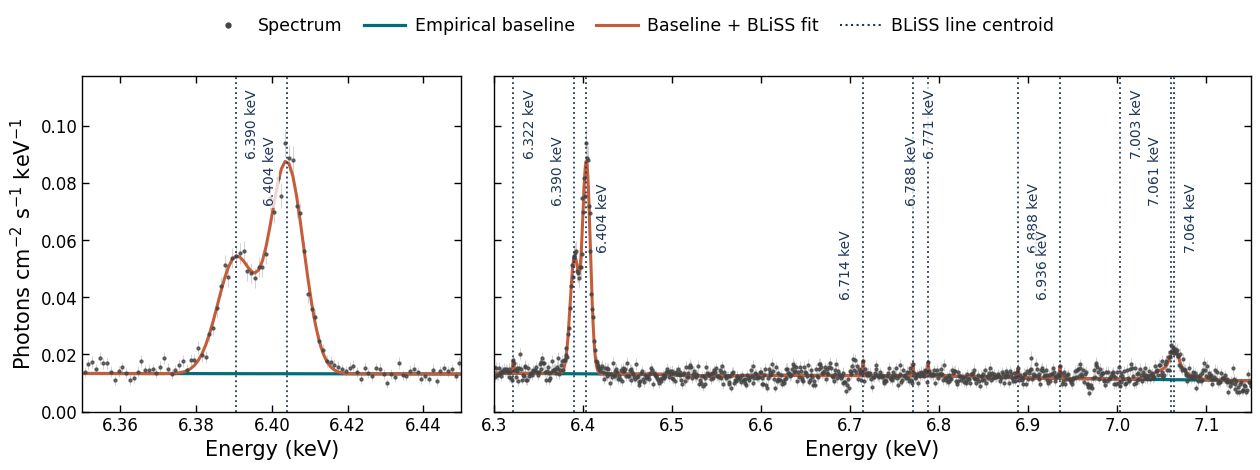

In [13]:
# ============================================================
# XRISM Fe zoom plot: two panels with fitted-line labels
# ============================================================
# ============================================================
# Paper plotting style
# ============================================================

from matplotlib.lines import Line2D

PAPER_COLORS = {
    "spectrum":   "#444444",
    "errors":     "#BDBDBD",
    "baseline":   "#006D77",
    "global_fit": "#C65D3A",
    "matched":    "#2A9D8F",
    "extra":      "#1D3557",
    "line":       "#1D3557",
}
plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 15,
    "axes.titlesize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ============================================================
# Helper functions
# ============================================================

def filter_bliss_lines_for_window(
    line_table,
    emin,
    emax,
    center_col="center",
    prob_col="cluster_probability",
    p_min=None,
    snr_min=None,
    snr_columns=("snr_peak", "snr_amplitude", "snr_area"),
    snr_mode="any",
    prob_snr_logic="and",
):
    """
    Select BLiSS lines whose fitted centroid lies inside an energy window.
    Optionally apply probability and/or SNR cuts.
    """

    if line_table is None or len(line_table) == 0:
        return pd.DataFrame()

    df = line_table.copy()

    if center_col not in df.columns:
        return pd.DataFrame(columns=df.columns)

    # --------------------------------------------------------
    # Numeric safety
    # --------------------------------------------------------

    numeric_cols = [center_col, prob_col] + list(snr_columns)

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # --------------------------------------------------------
    # Energy-window selection
    # --------------------------------------------------------

    mask_window = (
        np.isfinite(df[center_col])
        & (df[center_col] >= emin)
        & (df[center_col] <= emax)
    )

    # --------------------------------------------------------
    # Optional probability cut
    # --------------------------------------------------------

    if p_min is not None and prob_col in df.columns:
        mask_prob = (
            np.isfinite(df[prob_col])
            & (df[prob_col] >= p_min)
        )
    else:
        mask_prob = pd.Series(True, index=df.index)

    # --------------------------------------------------------
    # Optional SNR cut
    # --------------------------------------------------------

    available_snr_cols = [col for col in snr_columns if col in df.columns]

    if snr_min is not None and len(available_snr_cols) > 0:

        snr_matrix = df[available_snr_cols].apply(
            pd.to_numeric,
            errors="coerce",
        )

        if snr_mode == "any":
            mask_snr = (snr_matrix >= snr_min).any(axis=1)
        elif snr_mode == "all":
            mask_snr = (snr_matrix >= snr_min).all(axis=1)
        else:
            raise ValueError("snr_mode must be 'any' or 'all'.")

    else:
        mask_snr = pd.Series(True, index=df.index)

    # --------------------------------------------------------
    # Combine probability and SNR cuts
    # --------------------------------------------------------

    if prob_snr_logic == "and":
        mask_quality = mask_prob & mask_snr
    elif prob_snr_logic == "or":
        mask_quality = mask_prob | mask_snr
    else:
        raise ValueError("prob_snr_logic must be 'and' or 'or'.")

    # --------------------------------------------------------
    # Final selection
    # --------------------------------------------------------

    out = df.loc[mask_window & mask_quality].copy()
    out = out.sort_values(center_col).reset_index(drop=True)

    return out


def get_plot_line_label(row, mode="energy"):
    """
    Return the label used for vertical line annotations.

    mode = "energy", "ion", or "both"
    """

    center = pd.to_numeric(row.get("center", np.nan), errors="coerce")

    if np.isfinite(center):
        energy_label = f"{center:.3f} keV"
    else:
        energy_label = ""

    ion_label = ""

    for col in ["ion", "Ion", "most_probable_ion", "line_id", "Line ID"]:
        if col in row.index and pd.notna(row[col]):
            value = str(row[col]).strip()
            if value.lower() not in ["nan", "none", ""]:
                ion_label = value.replace("_", " ")
                break

    if mode == "energy":
        return energy_label

    if mode == "ion":
        return ion_label if ion_label != "" else energy_label

    if mode == "both":
        if ion_label != "":
            return f"{ion_label}\n{energy_label}"
        return energy_label

    raise ValueError("mode must be 'energy', 'ion', or 'both'.")


# ============================================================
# Configuration
# ============================================================

name = "XRISM"
window_name = "fe_6p0_7p5keV"
key = (name, window_name)

zoom_ranges = [
    (6.35, 6.45),
    (6.3, 7.15),
]

# Label options: "energy", "ion", or "both"
line_label_mode = "energy"
line_label_fontsize = 10

# Use post-global-fit line table
line_table = vela_window_global_lines.get(key, pd.DataFrame())

snr_columns = (
    "snr_peak",
    "snr_amplitude",
    "snr_area",
)

snr_mode = "any"
prob_snr_logic = "and"

try:
    figures_dir = NOTEBOOKS_DIR / "figures"
except NameError:
    figures_dir = Path("figures")

figures_dir.mkdir(parents=True, exist_ok=True)


# ============================================================
# Recover full spectrum
# ============================================================

spec = vela_spectra[name]

energy_full = np.asarray(spec["energy"], dtype=float)
values_full = np.asarray(spec["values"], dtype=float)
errors_full = np.asarray(spec["errors"], dtype=float)


# ============================================================
# Restrict to the Fe window used in the global fit
# ============================================================

emin, emax = energy_windows_victoria[window_name]

mask_window = (
    (energy_full >= emin)
    & (energy_full <= emax)
)

energy = energy_full[mask_window]
values = values_full[mask_window]
errors = errors_full[mask_window]

base = np.asarray(
    vela_window_baselines[key],
    dtype=float,
)

yfit = np.asarray(
    vela_window_yfit.get(key, np.zeros_like(energy)),
    dtype=float,
)

if len(base) != len(energy):
    raise ValueError(
        f"base and energy do not have the same length: "
        f"len(base)={len(base)}, len(energy)={len(energy)}"
    )

if len(yfit) != len(energy):
    yfit = np.zeros_like(energy)


# ============================================================
# Common y-axis limit
# ============================================================

global_ymax = 0.0

for xmin, xmax in zoom_ranges:

    mask_zoom = (
        (energy >= xmin)
        & (energy <= xmax)
    )

    if np.any(mask_zoom):
        ymax = np.nanmax(values[mask_zoom])
        if np.isfinite(ymax):
            global_ymax = max(global_ymax, ymax)

if global_ymax <= 0:
    global_ymax = np.nanmax(values) if len(values) > 0 else 1.0


# ============================================================
# Plot: one row, two zooms
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12.8, 4.6),
    sharey=True,
    squeeze=False,
    gridspec_kw={"width_ratios": [1, 2]},
)

axes = axes[0]

for ax, (xmin, xmax) in zip(axes, zoom_ranges):

    mask_zoom = (
        (energy >= xmin)
        & (energy <= xmax)
    )

    e = energy[mask_zoom]
    v = values[mask_zoom]
    err = errors[mask_zoom]
    b = base[mask_zoom]
    yf = yfit[mask_zoom]

    if len(e) == 0:
        ax.text(
            0.5,
            0.5,
            "No data",
            transform=ax.transAxes,
            ha="center",
            va="center",
        )
        ax.set_xlim(xmin, xmax)
        ax.tick_params(
            direction="in",
            top=True,
            right=True,
            length=5,
            width=1.0,
            labelsize=12,
        )
        continue

    ylines = np.maximum(v - b, 0.0)

    # --------------------------------------------------------
    # Filter line table in this zoom window
    # --------------------------------------------------------

    lines_zoom = filter_bliss_lines_for_window(
        line_table,
        emin=xmin,
        emax=xmax,
    )

    # --------------------------------------------------------
    # Spectrum
    # --------------------------------------------------------

    ax.errorbar(
        e,
        v,
        yerr=err,
        fmt=".",
        markersize=4.2,
        linewidth=0.7,
        elinewidth=0.6,
        alpha=0.78,
        color=PAPER_COLORS["spectrum"],
        ecolor=PAPER_COLORS["errors"],
        label="Spectrum",
    )

    # --------------------------------------------------------
    # Baseline
    # --------------------------------------------------------

    ax.plot(
        e,
        b,
        linewidth=2.3,
        label="Empirical baseline",
        color=PAPER_COLORS["baseline"]
    )

    # --------------------------------------------------------
    # Baseline + global fit
    # --------------------------------------------------------

    if len(yf) == len(e) and np.any(np.isfinite(yf)) and np.nanmax(yf) > 0:
        ax.plot(
            e,
            b + yf,
            linewidth=2.2,
            linestyle="-",
            color=PAPER_COLORS["global_fit"],
            label="Baseline + BLiSS fit",
        )

    # --------------------------------------------------------
    # Candidate / fitted line centroids
    # --------------------------------------------------------

    if len(lines_zoom) > 0:

        # y positions are alternated to reduce overlap between close labels
        label_y_positions = [0.96, 0.82, 0.68, 0.54]

        for i, (_, row) in enumerate(lines_zoom.iterrows()):

            center = pd.to_numeric(row.get("center", np.nan), errors="coerce")

            if not np.isfinite(center):
                continue

            label = get_plot_line_label(
                row,
                mode=line_label_mode,
            )

            if label == "":
                continue

            x_offset = 7 if i % 2 == 0 else -7
            ha = "left" if x_offset > 0 else "right"
            y_frac = label_y_positions[i % len(label_y_positions)]

            ax.axvline(
                center,
                color=PAPER_COLORS["line"],
                linestyle=":",
                linewidth=1.35,
                alpha=0.92,
                zorder=3,
            )

            ax.annotate(
                label,
                xy=(center, y_frac),
                xycoords=("data", "axes fraction"),
                xytext=(x_offset, 0),
                textcoords="offset points",
                rotation=90,
                va="top",
                ha=ha,
                fontsize=line_label_fontsize,
                color=PAPER_COLORS["line"],
                zorder=4,
                bbox=dict(
                    boxstyle="round,pad=0.15",
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.76,
                ),
            )

    # --------------------------------------------------------
    # Axes formatting
    # --------------------------------------------------------

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(0, 1.25 * global_ymax)

    #ax.set_title(
    #    f"{name}: {xmin:.1f}--{xmax:.1f} keV",
    #    fontsize=11,
    #)

    ax.set_xlabel("Energy (keV)", fontsize=15)
    ax.tick_params(
        direction="in",
        top=True,
        right=True,
        length=5,
        width=1.0,
        labelsize=12,
    )


axes[0].set_ylabel(r"Photons cm$^{-2}$ s$^{-1}$ keV$^{-1}$", fontsize=15)


# ============================================================
# Legend
# ============================================================

legend_handles = [
    Line2D(
        [0],
        [0],
        marker=".",
        linestyle="None",
        color=PAPER_COLORS["spectrum"],
        markersize=7,
        label="Spectrum",
    ),
    Line2D(
        [0],
        [0],
        color=PAPER_COLORS["baseline"],
        linewidth=2.3,
        label="Empirical baseline",
    ),
    Line2D(
        [0],
        [0],
        color=PAPER_COLORS["global_fit"],
        linewidth=2.2,
        label="Baseline + BLiSS fit",
    ),
    Line2D(
        [0],
        [0],
        color=PAPER_COLORS["line"],
        linewidth=1.5,
        linestyle=":",
        label="BLiSS line centroid",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=4,
    fontsize=12.5,
    frameon=False,
    bbox_to_anchor=(0.5, 1.04),
    handlelength=2.4,
    columnspacing=1.2,
    handletextpad=0.55,
)

plt.tight_layout(rect=[0, 0, 1, 0.92])


# ============================================================
# Save
# ============================================================

fig.savefig(
    figures_dir / "xrism_fe_zoom_row.pdf",
    bbox_inches="tight",
)

fig.savefig(
    figures_dir / "xrism_fe_zoom_row_snr6.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [14]:
line_table

,ion,center,ecenter,sigma,esigma,amplitude,eamplitude,relative_power,noise_on_block,value_on_line,...,snr_peak,snr_amplitude,area,earea,snr_area,ew,cluster_probability,fit_error_flag,victoria_match,victoria_line_id
0,fe_xx,6.267963,6.343573e+01,0.000231,9.836833e+01,0.019679,3.833986e+04,0.117866,0.001858,0.017134,...,10.590631,5.132780e-07,0.000011,2.273312e+01,5.014493e-07,0.267230,1.0,unconstrained,False,--
1,fe_xxi,6.322020,1.019611e+00,0.000258,7.713824e+00,0.026337,2.967426e+03,0.144961,0.001883,0.017938,...,13.986083,8.875319e-06,0.000017,1.982777e+00,8.577605e-06,0.339100,1.0,unconstrained,False,--
2,fe_x,6.390474,3.430649e-04,0.004749,2.763231e-04,0.040360,1.515135e-03,0.608945,0.002968,0.054639,...,13.599615,2.663765e+01,0.000480,3.326876e-05,1.444218e+01,46.319590,1.0,,False,--
3,fe_x,6.403939,1.952392e-04,0.004450,1.567428e-04,0.073756,1.924274e-03,0.752976,0.002968,0.094097,...,24.852803,3.832914e+01,0.000823,3.606072e-05,2.281243e+01,65.479451,1.0,,False,--
4,fe_xxv,6.714129,3.115806e+01,0.000232,3.946687e+01,0.024565,1.868132e+04,0.172061,0.001812,0.017856,...,13.555320,1.314941e-06,0.000014,1.114769e+01,1.283316e-06,0.415636,1.0,unconstrained,False,--
5,fe_xxv,6.770963,3.498541e+01,0.000234,5.469481e+01,0.022125,2.319086e+04,0.143896,0.001791,0.016776,...,12.356748,9.540468e-07,0.000013,1.391632e+01,9.311070e-07,0.336170,1.0,unconstrained,False,--
6,fe_xxv,6.787944,1.311980e-01,0.000290,2.028923e-01,0.012697,2.555577e+01,0.159394,0.001804,0.017271,...,7.038671,4.968294e-04,0.000009,1.964838e-02,4.692325e-04,0.379182,1.0,unconstrained,False,--
7,fe_xxv,6.888078,3.858361e-01,0.000278,1.308950e+00,0.012774,1.932220e+02,0.120712,0.001773,0.015172,...,7.203306,6.611013e-05,0.000009,1.410331e-01,6.312342e-05,0.436125,1.0,unconstrained,False,--
8,fe_xxvi,6.935687,3.899647e-04,0.000640,3.087937e-04,0.004509,2.139010e-03,0.159376,0.001775,0.016018,...,2.539556,2.107895e+00,0.000007,4.895396e-06,1.478181e+00,0.615928,1.0,,False,--
9,fe_xii,7.003251,3.850768e-09,0.000008,3.778790e-10,0.092910,1.121462e-09,0.227674,0.001985,0.017765,...,46.804989,8.284705e+07,0.000002,8.800439e-11,2.234543e+04,NaN,1.0,,False,--


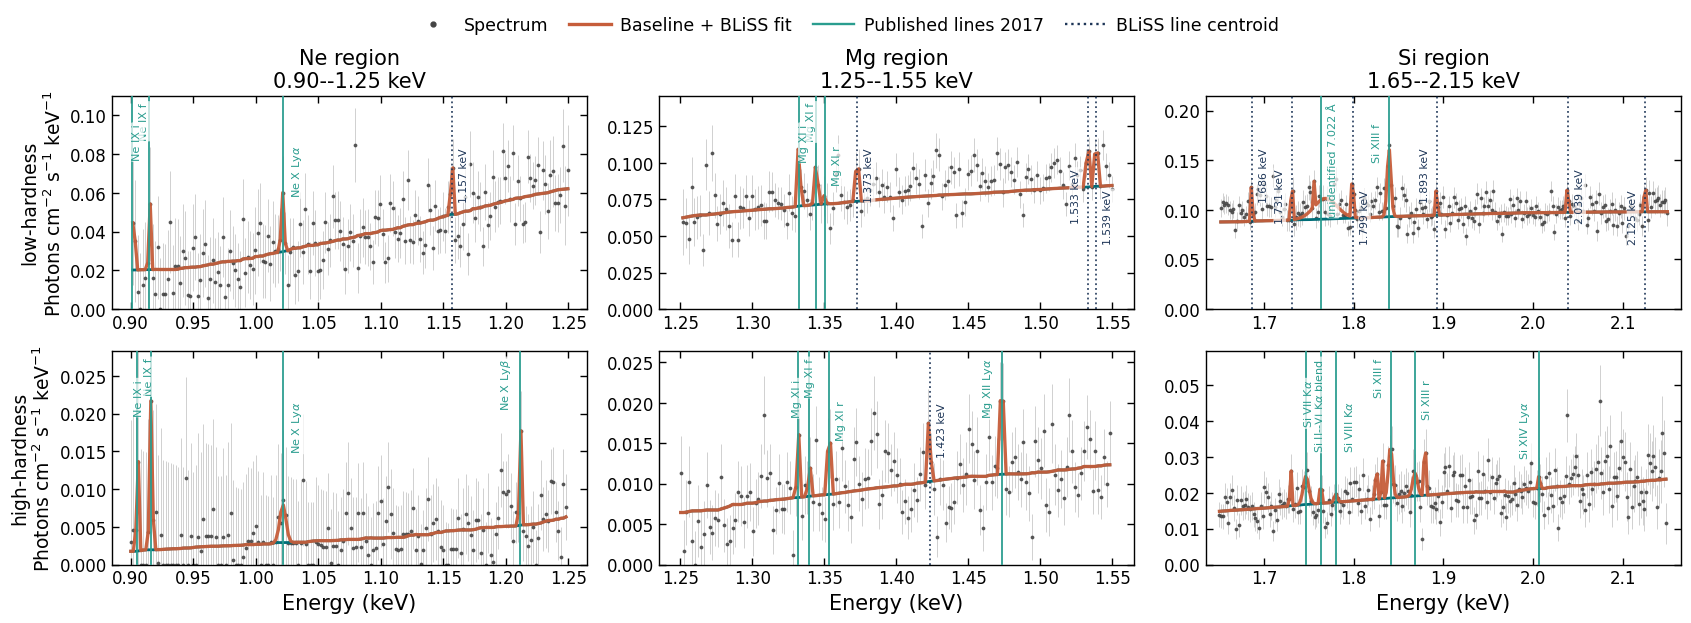

In [15]:
# ============================================================
# Chandra comparison plot after global fit:
# Victoria+BLiSS matched lines + additional global-fit lines
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ============================================================
# Paper plotting style
# ============================================================

PAPER_COLORS = {
    "spectrum":   "#444444",
    "errors":     "#BDBDBD",
    "baseline":   "#006D77",
    "global_fit": "#C65D3A",
    "matched":    "#2A9D8F",
    "extra":      "#1D3557",
    "line":       "#1D3557",
}

plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 15,
    "axes.titlesize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

colors = PAPER_COLORS

show_line_labels = True

# Labels for the vertical lines:
# - "energy": show only fitted energy
# - "id": show Victoria/ion label if available
# - "both": show label + energy
matched_label_mode = "id"
extra_label_mode = "energy"

extra_match_tolerance_keV = 0.02


# ============================================================
# Configuration
# ============================================================

obs_order = [
    "Chandra low-hardness",
    "Chandra high-hardness",
]

window_order = [
    "ne_0p90_1p25keV",
    "mg_1p25_1p55keV",
    "si_1p65_2p15keV",
]

window_labels = {
    "ne_0p90_1p25keV": "Ne region\n0.90--1.25 keV",
    "mg_1p25_1p55keV": "Mg region\n1.25--1.55 keV",
    "si_1p65_2p15keV": "Si region\n1.65--2.15 keV",
}


# ============================================================
# Helpers
# ============================================================

def _get_first_existing_col(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


def latex_like_label(label):
    """Make common line labels prettier for plot annotations."""

    if pd.isna(label):
        return ""

    label = str(label).strip()

    replacements = {
        "Lyα": r"Ly$\alpha$",
        "Lyβ": r"Ly$\beta$",
        "Kα": r"K$\alpha$",
        "Kβ": r"K$\beta$",
        "II–VI": "II--VI",
        "_": " ",
    }

    for old, new in replacements.items():
        label = label.replace(old, new)

    return label


def format_vertical_label(center, label=None, mode="energy"):
    """Return label for vertical line annotations."""

    energy_label = f"{center:.3f} keV"

    if label is None or str(label).strip() == "":
        label = energy_label
    else:
        label = latex_like_label(label)

    if mode == "energy":
        return energy_label

    if mode == "id":
        return label

    if mode == "both":
        return f"{label}\n{energy_label}"

    raise ValueError("mode must be 'energy', 'id', or 'both'.")


def annotate_vertical_line(
    ax,
    center,
    label,
    color,
    y_frac=0.96,
    x_offset=5,
    fontsize=8.0,
    linestyle="-",
    linewidth=1.1,
    alpha=0.95,
):
    """Draw one vertical line and a slightly offset rotated label."""

    ax.axvline(
        center,
        color=color,
        linestyle=linestyle,
        linewidth=linewidth,
        alpha=alpha,
        zorder=3,
    )

    if label is None or label == "":
        return

    ha = "left" if x_offset > 0 else "right"

    ax.annotate(
        label,
        xy=(center, y_frac),
        xycoords=("data", "axes fraction"),
        xytext=(x_offset, 0),
        textcoords="offset points",
        rotation=90,
        fontsize=fontsize,
        ha=ha,
        va="top",
        color=color,
        zorder=4,
        bbox=dict(
            boxstyle="round,pad=0.12",
            facecolor="white",
            edgecolor="none",
            alpha=0.72,
        ),
    )


def get_matched_bliss_centers(
    match_table,
    observation,
    window_name,
):
    """
    Return centers of BLiSS candidates matched to Victoria lines.
    """

    if match_table is None or len(match_table) == 0:
        return np.array([]), {}

    df = match_table.copy()

    obs_col = _get_first_existing_col(
        df,
        ["our_observation", "observation", "obs"],
    )

    window_col = _get_first_existing_col(
        df,
        ["window", "region"],
    )

    match_col = _get_first_existing_col(
        df,
        ["match_within_tolerance", "matched", "recovered"],
    )

    center_col = _get_first_existing_col(
        df,
        ["candidate_center", "candidate_center_keV", "center"],
    )

    lineid_col = _get_first_existing_col(
        df,
        ["line_id", "Line ID"],
    )

    if any(col is None for col in [obs_col, window_col, match_col, center_col]):
        return np.array([]), {}

    df = df[
        (df[obs_col] == observation)
        & (df[window_col] == window_name)
    ].copy()

    if len(df) == 0:
        return np.array([]), {}

    df[match_col] = df[match_col].fillna(False).astype(bool)
    df[center_col] = pd.to_numeric(df[center_col], errors="coerce")

    df = df[df[match_col] & np.isfinite(df[center_col])].copy()

    if len(df) == 0:
        return np.array([]), {}

    centers = np.sort(
        np.unique(
            np.round(df[center_col].to_numpy(dtype=float), 6)
        )
    )

    labels_by_center = {}

    if lineid_col is not None:
        for c in centers:
            close = df[np.abs(df[center_col] - c) < 1e-6]

            if len(close) > 0:
                labels_by_center[c] = latex_like_label(close.iloc[0][lineid_col])
            else:
                labels_by_center[c] = f"{c:.3f}"

    return centers, labels_by_center


def get_global_fit_centers(global_lines):
    """
    Return all global-fit line centers.
    """

    if global_lines is None or len(global_lines) == 0:
        return np.array([]), {}

    df = global_lines.copy()

    if "center" not in df.columns:
        return np.array([]), {}

    df["center"] = pd.to_numeric(df["center"], errors="coerce")
    df = df[np.isfinite(df["center"])].copy()

    if len(df) == 0:
        return np.array([]), {}

    centers = np.sort(
        np.unique(
            np.round(df["center"].to_numpy(dtype=float), 6)
        )
    )

    labels_by_center = {}

    ion_col = _get_first_existing_col(
        df,
        ["ion", "Ion", "most_probable_ion", "line_id", "Line ID"],
    )

    for c in centers:

        close = df[np.abs(df["center"] - c) < 1e-6]

        if len(close) == 0:
            labels_by_center[c] = f"{c:.3f}"
            continue

        if ion_col is not None and pd.notna(close.iloc[0][ion_col]):
            labels_by_center[c] = latex_like_label(close.iloc[0][ion_col])
        else:
            labels_by_center[c] = f"{c:.3f}"

    return centers, labels_by_center


def remove_centers_close_to_matched(
    centers,
    matched_centers,
    tolerance_keV=0.02,
):
    """
    Remove global-fit centers already represented by Victoria+BLiSS matched lines.
    """

    centers = np.asarray(centers, dtype=float)
    matched_centers = np.asarray(matched_centers, dtype=float)

    if len(centers) == 0:
        return np.array([])

    if len(matched_centers) == 0:
        return centers

    extra = []

    for c in centers:
        if np.all(np.abs(matched_centers - c) > tolerance_keV):
            extra.append(c)

    return np.asarray(extra, dtype=float)


# ============================================================
# Figure
# ============================================================

nrows = len(obs_order)
ncols = len(window_order)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5.70 * ncols, 3.55 * nrows),
    sharex=False,
    sharey=False,
    squeeze=False,
)

for i, obs in enumerate(obs_order):

    spec = vela_spectra[obs]

    energy_full = np.asarray(spec["energy"], dtype=float)
    values_full = np.asarray(spec["values"], dtype=float)
    errors_full = np.asarray(spec["errors"], dtype=float)

    if "baseline" not in spec:
        raise ValueError(
            f"No baseline found in vela_spectra['{obs}']. "
            "Run the baseline cell first."
        )

    baseline_full = np.asarray(spec["baseline"], dtype=float)

    valid = (
        np.isfinite(energy_full)
        & np.isfinite(values_full)
        & np.isfinite(errors_full)
        & np.isfinite(baseline_full)
        & (errors_full > 0)
    )

    energy_full = energy_full[valid]
    values_full = values_full[valid]
    errors_full = errors_full[valid]
    baseline_full = baseline_full[valid]

    order = np.argsort(energy_full)

    energy_full = energy_full[order]
    values_full = values_full[order]
    errors_full = errors_full[order]
    baseline_full = baseline_full[order]

    for j, window_name in enumerate(window_order):

        ax = axes[i, j]

        key = (obs, window_name)

        emin, emax = energy_windows_victoria[window_name]

        mask = (
            (energy_full >= emin)
            & (energy_full <= emax)
        )

        energy = energy_full[mask]
        values = values_full[mask]
        errors = errors_full[mask]
        baseline = baseline_full[mask]

        if len(energy) == 0:
            ax.text(
                0.5,
                0.5,
                "No data",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=13,
            )
            ax.set_xlim(emin, emax)
            ax.tick_params(
                direction="in",
                top=True,
                right=True,
                length=5,
                width=1.0,
                labelsize=12,
            )
            continue

        # ----------------------------------------------------
        # Global fit for this window
        # ----------------------------------------------------

        global_lines = vela_window_global_lines.get(key, pd.DataFrame())

        global_centers, global_labels = get_global_fit_centers(global_lines)

        yfit = np.asarray(
            vela_window_yfit.get(key, np.zeros_like(energy)),
            dtype=float,
        )

        if len(yfit) != len(energy):
            yfit = np.zeros_like(energy)

        # ----------------------------------------------------
        # Matched Victoria + BLiSS lines
        # ----------------------------------------------------

        matched_centers, matched_labels = get_matched_bliss_centers(
            victoria_chandra_candidate_matches,
            observation=obs,
            window_name=window_name,
        )

        extra_global_centers = remove_centers_close_to_matched(
            global_centers,
            matched_centers,
            tolerance_keV=extra_match_tolerance_keV,
        )

        # ----------------------------------------------------
        # Spectrum and baseline
        # ----------------------------------------------------

        ax.errorbar(
            energy,
            values,
            yerr=errors,
            fmt=".",
            color=colors["spectrum"],
            ecolor=colors["errors"],
            markersize=3.5,
            linewidth=0.60,
            elinewidth=0.60,
            alpha=0.82,
            zorder=1,
        )

        ax.plot(
            energy,
            baseline,
            color=colors["baseline"],
            linewidth=2.0,
            zorder=2,
        )

        # ----------------------------------------------------
        # Baseline + global fit
        # ----------------------------------------------------

        if np.any(np.isfinite(yfit)) and np.nanmax(yfit) > 0:
            ax.plot(
                energy,
                baseline + yfit,
                color=colors["global_fit"],
                linestyle="-",
                linewidth=2.4,
                alpha=0.95,
                zorder=2.5,
            )

        # ----------------------------------------------------
        # Victoria + BLiSS matched lines
        # ----------------------------------------------------

        for k, center in enumerate(matched_centers):

            raw_label = matched_labels.get(center, f"{center:.3f}")

            label = format_vertical_label(
                center,
                label=raw_label,
                mode=matched_label_mode,
            )

            y_frac = 0.97 - 0.10 * (k % 3)
            x_offset = 5 if k % 2 == 0 else -5

            annotate_vertical_line(
                ax,
                center=center,
                label=label if show_line_labels else "",
                color=colors["matched"],
                y_frac=y_frac,
                x_offset=x_offset,
                fontsize=8.1,
                linestyle="-",
                linewidth=1.35,
                alpha=0.95,
            )

        # ----------------------------------------------------
        # Additional global-fit lines
        # ----------------------------------------------------

        for k, center in enumerate(extra_global_centers):

            raw_label = global_labels.get(center, f"{center:.3f}")

            label = format_vertical_label(
                center,
                label=raw_label,
                mode=extra_label_mode,
            )

            y_frac = 0.76 - 0.10 * (k % 3)
            x_offset = 5 if k % 2 == 0 else -5

            annotate_vertical_line(
                ax,
                center=center,
                label=label if show_line_labels else "",
                color=colors["extra"],
                y_frac=y_frac,
                x_offset=x_offset,
                fontsize=7.8,
                linestyle=":",
                linewidth=1.30,
                alpha=0.90,
            )

        # ----------------------------------------------------
        # Formatting
        # ----------------------------------------------------

        ax.set_xlim(emin-0.015, emax+0.015)

        ymax = np.nanmax(values)

        if np.isfinite(ymax) and ymax > 0:
            ax.set_ylim(0, 1.30 * ymax)

        ax.tick_params(
            direction="in",
            top=True,
            right=True,
            length=5,
            width=1.0,
            labelsize=12,
        )

        if i == 0:
            ax.set_title(
                window_labels.get(window_name, window_name),
                fontsize=15,
            )

        if j == 0:
            obs_label = obs.replace("Chandra ", "")
            ax.set_ylabel(
                rf"{obs_label}"
                "\n"
                r"Photons cm$^{-2}$ s$^{-1}$ keV$^{-1}$",
                fontsize=13.5,
            )

        if i == nrows - 1:
            ax.set_xlabel("Energy (keV)", fontsize=15)


# ============================================================
# Legend below panels
# ============================================================

legend_handles = [
    Line2D(
        [0],
        [0],
        marker=".",
        linestyle="None",
        color=colors["spectrum"],
        markersize=7,
        label="Spectrum",
    ),
   
    Line2D(
        [0],
        [0],
        color=colors["global_fit"],
        linewidth=2.4,
        linestyle="-",
        label="Baseline + BLiSS fit",
    ),
    Line2D(
        [0],
        [0],
        color=colors["matched"],
        linewidth=1.7,
        linestyle="-",
        label="Published lines 2017",
    ),
    Line2D(
        [0],
        [0],
        color=colors["extra"],
        linewidth=1.7,
        linestyle=":",
        label="BLiSS line centroid",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=4,
    fontsize=12.5,
    frameon=False,
    bbox_to_anchor=(0.5, 1.04),
    handlelength=2.4,
    columnspacing=1.2,
    handletextpad=0.55,
)

plt.tight_layout(rect=[0, 0.15, 1, 1.0])


# ============================================================
# Save
# ============================================================

try:
    figures_dir = NOTEBOOKS_DIR / "figures"
except NameError:
    figures_dir = Path("vela_line_search_results_windows") / "figures"

figures_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    figures_dir / "vela_x1_chandra_victoria.pdf",
    bbox_inches="tight",
    pad_inches=0.04,
)

fig.savefig(
    figures_dir / "vela_x1_chandra_victoria_global_fit_comparison_grid_snr6.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.04,
)

plt.show()